In [17]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

import util
from plot_setup import *

FOLDER = "/Users/brendan/Projects/trails/data/"

# SIZE = 10000
STEPS = 20000


datafiles = [
    # "SVD-zoom|2026-01-14/data.json",
    "SVD|2026-01-09/data.json",
]

In [18]:
dfs = [
    util.load_data(FOLDER + datafile) for datafile in datafiles
]
df = pd.concat(dfs)
util.describe(df)
df.columns

ratios: [100.0]
patch recovery: [0.001 0.0005]
max costs: [2.0 8.0]
boundary conditions: ['PERIODIC' 'SOLID']
num locations: [8 16]
random walker seeds: 64
random locations seeds: 2
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
settings.scenario : ['RANDOM_FIXED']
settings.X : [100]
steps: 20000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy',
       'settings.scenario', 'settings.X', 'ratio'],
      dtype='object')


Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy',
       'settings.scenario', 'settings.X', 'ratio'],
      dtype='object')

#  Currently in the paper:

`print(seed, numLocations, p, cost, pR)`

- 1 8 PERIODIC 8.0 0.001 (multiple solutions)
- 1 8 SOLID 8.0 0.001 (1 solution)

could try for multiple:
- 1 8 SOLID 2.0 0.0005
- 1 8 PERIODIC 8.0 0.0005
- 1 16 PERIODIC 2.0 0.0005

could try for single:
1 16 SOLID 8.0 0.0005

In [19]:
def apply_svd(data):
    _final = data[data["steps"] == STEPS]
    patches = _final["patches"]
    N = len(_final)
    
    
    num_observations = len(patches)
    num_features = len(patches.iloc[0])
    # observations as rows, features as columns
    A = np.reshape(patches.explode(), (num_observations, num_features)).astype(float)
    
    U, S, Vh = np.linalg.svd(A, full_matrices=False)
    
    # decompose the patches into their components vs the SVD and add it to
    # the full dataframe
    DIMENSIONS_TO_SHOW = 3
    
    # map the dimensions back across
    for i in range(DIMENSIONS_TO_SHOW):
        data[f"U{i}"] = data["patches"].map(lambda p: p @ Vh.T[:, i])


    final = data[data["steps"] == STEPS]

    U1s = {}
    for _, r in final.iterrows():
        U1s[r["settings.randomSeedWalkers"]] = r["U1"]

    data["finalU1"] = data.apply(lambda r: U1s[r["settings.randomSeedWalkers"]], axis=1)

In [101]:
# Perform the SVD
# This one has multiple solutions.

ex_1 = df[
    (df["settings.patchRecovery"] == 0.0005) &
    # (df["steps"] == steps) &
    (df["settings.numLocations"] == 8) &
    (df["settings.randomSeedLocations"] == 1) &
    (df["settings.boundaryConditions"] == "SOLID") &
    (df["settings.maxCost"] == 2.0)
].copy()


ex_2 = df[
    (df["settings.patchRecovery"] == 0.001) &
    # (df["steps"] == steps) &
    (df["settings.numLocations"] == 8) &
    (df["settings.randomSeedLocations"] == 1) &
    (df["settings.boundaryConditions"] == "SOLID") &
    (df["settings.maxCost"] == 8.0)
].copy()

apply_svd(ex_1)
apply_svd(ex_2)

# U, S, Vh = util.svd(_all, steps, dynamics=True)

/var/folders/q_/ntb72mmd6jd72ljyc9qyw4100000gn/T/ipykernel_22855/4006323167.py:20: RuntimeWarning: divide by zero encountered in matmul
  data[f"U{i}"] = data["patches"].map(lambda p: p @ Vh.T[:, i])
/var/folders/q_/ntb72mmd6jd72ljyc9qyw4100000gn/T/ipykernel_22855/4006323167.py:20: RuntimeWarning: overflow encountered in matmul
  data[f"U{i}"] = data["patches"].map(lambda p: p @ Vh.T[:, i])
/var/folders/q_/ntb72mmd6jd72ljyc9qyw4100000gn/T/ipykernel_22855/4006323167.py:20: RuntimeWarning: invalid value encountered in matmul
  data[f"U{i}"] = data["patches"].map(lambda p: p @ Vh.T[:, i])
/var/folders/q_/ntb72mmd6jd72ljyc9qyw4100000gn/T/ipykernel_22855/4006323167.py:20: RuntimeWarning: divide by zero encountered in matmul
  data[f"U{i}"] = data["patches"].map(lambda p: p @ Vh.T[:, i])
/var/folders/q_/ntb72mmd6jd72ljyc9qyw4100000gn/T/ipykernel_22855/4006323167.py:20: RuntimeWarning: overflow encountered in matmul
  data[f"U{i}"] = data["patches"].map(lambda p: p @ Vh.T[:, i])
/var/folders/

In [92]:
def plot_example_process(subfig, data):
    _, left_sub, _, right_sub, _ = subfig.subfigures(1, 5, width_ratios=(1, 3, 1, 3, 1))
    _final = data[data["steps"] == STEPS]
    patches = _final["patches"]
    N = len(_final)

    add_letter(left_sub, 0.05, 0.75, "i")

    
    num_observations = len(patches)
    num_features = len(patches.iloc[0])
    # observations as rows, features as columns
    A = np.reshape(patches.explode(), (num_observations, num_features)).astype(float)
    
    U, S, Vh = np.linalg.svd(A, full_matrices=False)

    axs = left_sub.subplots(3, 4)
    for i in range(12):
        ax = axs[i // 4][i % 4]
        row = data[data["steps"] == STEPS].iloc[i]
        ax.imshow(np.reshape(row["patches"], (100, 100)), cmap=CMAP)
        ax.axis('off')
        # ax.set_title(f"{round(row['U1'], 2)},{round(row['U2'], 2)}")

    top_fig, bot_fig = right_sub.subfigures(2, 1)

    
    add_letter(top_fig, 0.00, 0.75, "ii")
    add_letter(bot_fig, 0.0, 0.75, "iii")


    
    # plot the eigen-trails
    axs = top_fig.subplots(1, 4)
    for i in range(4):
        ax = axs[i]
        ax.imshow(np.reshape(Vh[i], (100, 100)), cmap=CMAP)
        ax.axis('off')
        # ax.set_title(f"{round(s[i], 2)}")

    ax = bot_fig.subplots()
    s = S**2/sum(S**2)
    # axs[0].bar([x for x in range(N)], S[:N]),
    sns.barplot(s[:4], ax=ax, color=COLORS[0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("principal component weights")
    # ax.set_ylabel(r"weight $\rightarrow$")


In [93]:
def plot_row(subfig, data):
    axs = subfig.subplots(1, 3)

    # Final U1 vs U2 plot.
    # TODO: scale by component weights (?)
    sns.scatterplot(
        ax=axs[0],
        data=data[data["steps"] == STEPS],
        x="U2", y="U1", hue="U1", legend=False,
    )
    axs[0].set_xticks([])
    axs[0].set_yticks([])
    axs[0].set_ylabel(r"1st component $\rightarrow$")
    axs[0].set_xlabel(r"2nd component $\rightarrow$")
    
    add_number(axs[0], 0.05, .9, "i")    
    add_number(axs[1], 0.05, .9, "ii")
    add_number(axs[2], 0.05, .9, "iii")



    # U1 vs U2 over time.
    sns.lineplot(
        ax=axs[1],
        data=data[data["steps"] >= 0],
        x="steps",
        y=f"U1",
        hue="finalU1",
        # hue="settings.randomSeedWalkers",
        style="settings.boundaryConditions",
        alpha=0.5,
        legend=False,
    )
    axs[1].set_xticks([])
    axs[1].set_yticks([])
    axs[1].set_xlabel(r"time $\rightarrow$")
    axs[1].set_ylabel(r"1st component $\rightarrow$")

    # 
    sns.scatterplot(
        ax=axs[2],
        data=data[data["steps"] == STEPS], y="averageTravelCost",
        hue="U1", x="totalImprovement", style="settings.boundaryConditions",
        legend=False,
    )
    axs[2].set_xticks([])
    axs[2].set_yticks([])
    axs[2].set_ylabel(r"travel costs $\rightarrow$")
    axs[2].set_xlabel(r"trail costs $\rightarrow$")



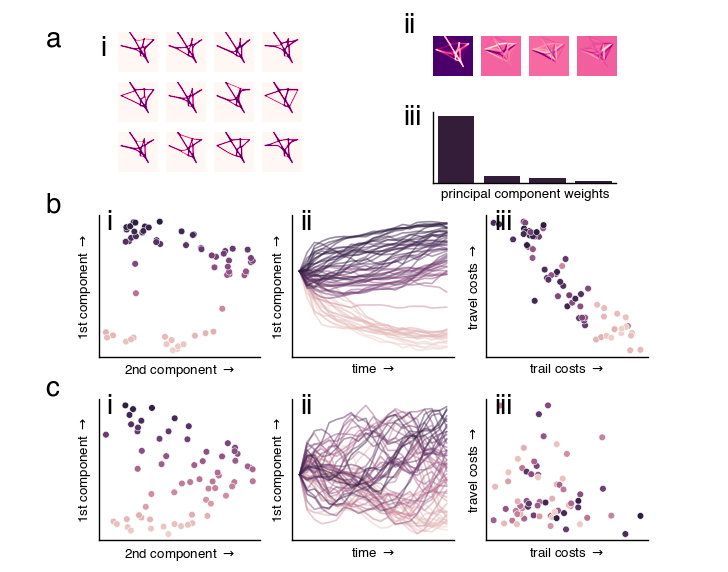

In [103]:
fig = plt.figure(figsize=(two_column_width, 140/mm_to_inch))
top_fig, mid_fig, bot_fig = fig.subfigures(3, 1, height_ratios=(2, 2, 2))

# mid_fig.suptitle("High clustering (multiple solutions)")
# bot_fig.suptitle("No clustering (single solution)")

add_letter(top_fig, 0.05, .8, "a")
add_letter(mid_fig, 0.05, .9, "b")
add_letter(bot_fig, 0.05, .9, "c")

plot_example_process(top_fig, ex_1)
plot_row(mid_fig, ex_1)
plot_row(bot_fig, ex_2)

fig.savefig("figures/5.pdf")
fig.savefig("figures/5.svg")

In [31]:

def add_number(ax, xoffset, yoffset, number):
    ax.text(xoffset, yoffset, number,
        transform = ax.transAxes,
        size=20, weight='bold')